In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile
import os

zipPath_labeled_images = "/content/drive/MyDrive/labeled_images.zip"  # Path to your zip
extractPath_labeled_images = "/content"  # Where to extract in Colab VM

zipPath_images_splits_csvs = "/content/drive/MyDrive/images_splits_csvs.zip"
extractPath_images_splits_csvs = "/content"

# Unzip
with zipfile.ZipFile(zipPath_labeled_images, 'r') as zip_ref:
    zip_ref.extractall(extractPath_labeled_images)


with zipfile.ZipFile(zipPath_images_splits_csvs, 'r') as zip_ref:
    zip_ref.extractall(extractPath_images_splits_csvs)

In [ ]:
!pip install timm torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 96.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
import os
import zipfile
import pandas as pd
from PIL import Image
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.transforms import InterpolationMode
import timm
import torch.nn as nn
import torch.optim as optim
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from torch.cuda.amp import GradScaler, autocast
import numpy as np
from torchvision.transforms import autoaugment

# Paths
IMG_CSV_DIR = "/content/images_splits_csvs"
IMG_ROOT = "/content/labeled_images"

# Load data
df_train = pd.read_csv(os.path.join(IMG_CSV_DIR, "train.csv"))
df_val = pd.read_csv(os.path.join(IMG_CSV_DIR, "val.csv"))
df_test = pd.read_csv(os.path.join(IMG_CSV_DIR, "test.csv"))

# Patient-level leakage check
def check_patient_leakage(df_train, df_val, df_test):
    train_patients = set(df_train['num patient'])
    val_patients = set(df_val['num patient'])
    test_patients = set(df_test['num patient'])
    assert len(train_patients & val_patients) == 0, "Patient leakage between train and val!"
    assert len(train_patients & test_patients) == 0, "Patient leakage between train and test!"
    assert len(val_patients & test_patients) == 0, "Patient leakage between val and test!"

check_patient_leakage(df_train, df_val, df_test)

# Label encoding
le = LabelEncoder()
df_train['label_enc'] = le.fit_transform(df_train['label'])
df_val['label_enc'] = le.transform(df_val['label'])
df_test['label_enc'] = le.transform(df_test['label'])
NUM_CLASSES = len(le.classes_)

# Transforms
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop((224, 224), scale=(0.75, 1.0), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    autoaugment.RandAugment(num_ops=2, magnitude=9),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3))
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224), interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dataset
class GastroDataset(Dataset):
    def __init__(self, dataframe, img_root, transform=None):
        self.df = dataframe
        self.img_root = os.path.normpath(img_root)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.normpath(os.path.join(self.img_root, str(row['num patient']), row['filename']))
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            image = Image.new('RGB', (224, 224))
        if self.transform:
            image = self.transform(image)
        return image, row['label_enc']

# Oversampling
class_counts = Counter(df_train['label_enc'])
class_weights = {i: 1.0 / count for i, count in class_counts.items()}
sample_weights = [class_weights[label] for label in df_train['label_enc']]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# Dataloaders
batch_size = 8
train_loader = DataLoader(
    GastroDataset(df_train, IMG_ROOT, train_transforms),
    batch_size=batch_size,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)
val_loader = DataLoader(
    GastroDataset(df_val, IMG_ROOT, val_test_transforms),
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
test_loader = DataLoader(
    GastroDataset(df_test, IMG_ROOT, val_test_transforms),
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha if alpha is not None else torch.ones(NUM_CLASSES).to(device)
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = (self.alpha[targets] * (1 - pt) ** self.gamma * ce_loss).mean()
        return focal_loss

# Model
model = timm.create_model(
    "vit_base_patch16_224.dino",
    pretrained=True,
    num_classes=NUM_CLASSES,
    drop_rate=0.3,
    drop_path_rate=0.2
).to(device)

# Optimizer, Scheduler, Loss
criterion = FocalLoss(gamma=2.0)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

# Validation
def validate(model, criterion, loader):
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = val_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, macro_f1, acc

# TTA prediction
def tta_predict(model, loader):
    model.eval()
    all_probs = []
    all_labels = []
    tta_transforms = [
        val_test_transforms,
        transforms.Compose([
            transforms.Resize((224, 224), interpolation=InterpolationMode.BICUBIC),
            transforms.RandomHorizontalFlip(p=1.0),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ]),
        transforms.Compose([
            transforms.Resize((224, 224), interpolation=InterpolationMode.BICUBIC),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    ]
    with torch.no_grad():
        for images, labels in loader:
            batch_probs = []
            for transform in tta_transforms:
                aug_images = torch.stack([transform(transforms.ToPILImage()(img.cpu())) for img in images])
                aug_images = aug_images.to(device)
                outputs = model(aug_images)
                probs = torch.softmax(outputs, dim=1)
                batch_probs.append(probs)
            avg_probs = torch.mean(torch.stack(batch_probs), dim=0)
            all_probs.extend(avg_probs.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_probs), np.array(all_labels)

# Train
def train_model(model, criterion, optimizer, scheduler, epochs=30, patience=5):
    scaler = GradScaler()
    best_val_acc = 0.0
    counter = 0
    accumulation_steps = 4
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        optimizer.zero_grad()
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels) / accumulation_steps
            scaler.scale(loss).backward()
            if (i + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            running_loss += loss.item() * accumulation_steps
        train_loss = running_loss / len(train_loader)
        val_loss, macro_f1, val_acc = validate(model, criterion, val_loader)
        scheduler.step()
        print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Macro-F1: {macro_f1:.4f}, "
              f"Val Acc: {val_acc:.4f}")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            counter = 0
            torch.save(model.state_dict(), "best_vit_model.pth")
            print("Best model saved.")
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered.")
                break

# Run training
train_model(model, criterion, optimizer, scheduler)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

<ipython-input-4-d676aa640fe3>:205: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
<ipython-input-4-d676aa640fe3>:215: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/30] Train Loss: 2.7769, Val Loss: 1.4620, Val Macro-F1: 0.3282, Val Acc: 0.3752
Best model saved.


<ipython-input-4-d676aa640fe3>:215: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

Epoch [27/30] Train Loss: 0.2012, Val Loss: 0.6280, Val Macro-F1: 0.7014, Val Acc: 0.7075


<ipython-input-4-d676aa640fe3>:215: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [28/30] Train Loss: 0.2049, Val Loss: 0.6290, Val Macro-F1: 0.7026, Val Acc: 0.7075


<ipython-input-4-d676aa640fe3>:215: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [29/30] Train Loss: 0.1995, Val Loss: 0.6307, Val Macro-F1: 0.7001, Val Acc: 0.7060
Early stopping triggered.


=== Classification Report ===
              precision    recall  f1-score   support

          A1       0.52      0.21      0.30        58
          A2       0.47      0.26      0.33        66
          A3       0.54      0.25      0.35        51
          A4       0.67      0.12      0.21        64
          A5       0.23      0.12      0.16        57
          A6       0.71      0.52      0.60        52
          G1       0.39      0.36      0.37        67
          G2       0.18      0.64      0.28        67
          G3       0.44      0.21      0.28        68
          G4       0.20      0.61      0.30        57
          L1       0.30      0.31      0.31        54
          L2       0.23      0.25      0.24        64
          L3       0.30      0.50      0.37        58
          L4       0.49      0.45      0.47        53
          L5       0.53      0.13      0.21        63
          L6       0.40      0.35      0.37        55
  OTHERCLASS       0.11      0.39      0.18        

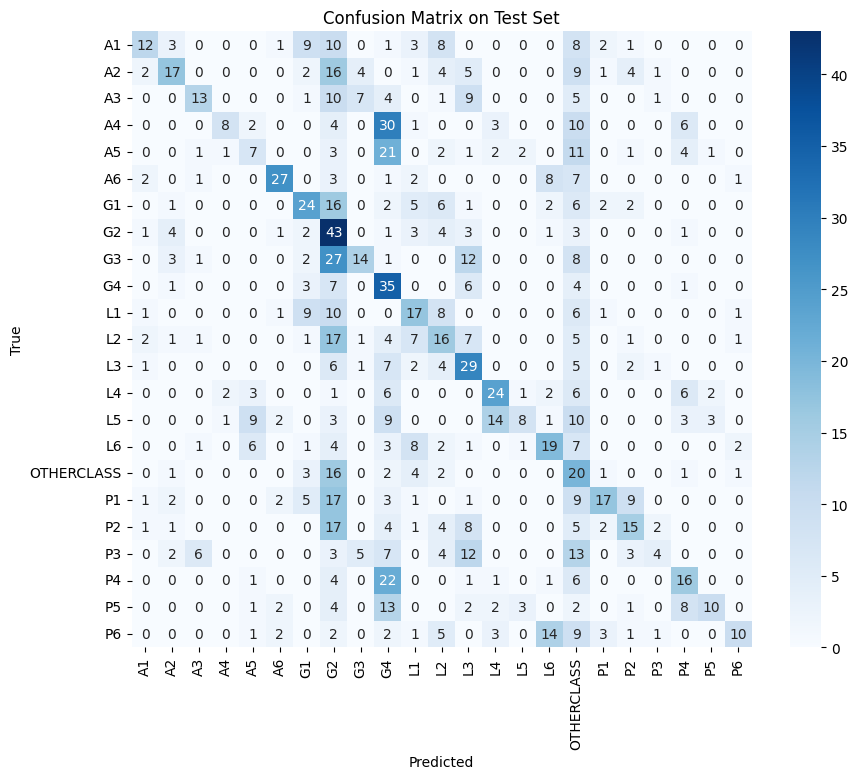


Test Accuracy: 0.3011
Test Macro-F1 Score: 0.3049

=== Sensitivity and Specificity per class ===
A1: Sensitivity (Recall) = 0.2069, Specificity = 0.9915
A2: Sensitivity (Recall) = 0.2576, Specificity = 0.9851
A3: Sensitivity (Recall) = 0.2549, Specificity = 0.9915
A4: Sensitivity (Recall) = 0.1250, Specificity = 0.9969
A5: Sensitivity (Recall) = 0.1228, Specificity = 0.9821
A6: Sensitivity (Recall) = 0.5192, Specificity = 0.9915
G1: Sensitivity (Recall) = 0.3582, Specificity = 0.9703
G2: Sensitivity (Recall) = 0.6418, Specificity = 0.8435
G3: Sensitivity (Recall) = 0.2059, Specificity = 0.9859
G4: Sensitivity (Recall) = 0.6140, Specificity = 0.8890
L1: Sensitivity (Recall) = 0.3148, Specificity = 0.9698
L2: Sensitivity (Recall) = 0.2500, Specificity = 0.9578
L3: Sensitivity (Recall) = 0.5000, Specificity = 0.9464
L4: Sensitivity (Recall) = 0.4528, Specificity = 0.9807
L5: Sensitivity (Recall) = 0.1270, Specificity = 0.9945
L6: Sensitivity (Recall) = 0.3455, Specificity = 0.9775
OTHERC

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Load best model
model.load_state_dict(torch.load("best_vit_model.pth"))
model.to(device)

# Run TTA prediction on test set
test_probs, test_labels = tta_predict(model, test_loader)
test_preds = np.argmax(test_probs, axis=1)

# Classification report
print("=== Classification Report ===")
print(classification_report(test_labels, test_preds, target_names=le.classes_))

# Confusion matrix
conf_matrix = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix on Test Set")
plt.show()

# Macro F1 & Accuracy
macro_f1 = f1_score(test_labels, test_preds, average='macro')
acc = accuracy_score(test_labels, test_preds)
print(f"\nTest Accuracy: {acc:.4f}")
print(f"Test Macro-F1 Score: {macro_f1:.4f}")

# Sensitivity and Specificity per class
TP = np.diag(conf_matrix)
FP = conf_matrix.sum(axis=0) - TP
FN = conf_matrix.sum(axis=1) - TP
TN = conf_matrix.sum() - (FP + FN + TP)

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print("\n=== Sensitivity and Specificity per class ===")
for i, cls in enumerate(le.classes_):
    print(f"{cls}: Sensitivity (Recall) = {sensitivity[i]:.4f}, Specificity = {specificity[i]:.4f}")

# (Optional) AUC if you're interested and have one-hot labels
# test_one_hot = np.eye(NUM_CLASSES)[test_labels]
# auc_score = roc_auc_score(test_one_hot, test_probs, average='macro', multi_class='ovr')
# print(f"Test AUC (macro-average): {auc_score:.4f}")
